<a href="https://colab.research.google.com/github/karamazovjk/university/blob/main/EstatisticaTrensSpikes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Observação: Atividade integralmente baseada em material didático do Prof. Boris Marin.


# **Análise exploratória de trens de disparo**

Comparando séries temporais de disparos






In [2]:
import numpy as np
import matplotlib.pyplot as plt

# O arquivo 'cinco_tipos.npy' contém séries de spikes para 5 células distintas
# Dados baseados em http://people.brandeis.edu/~pmiller/TEXTBOOK/CHAPTER3/spikes_cv_isis.m

def pega_dados(nome_arquivo):
    repo = 'https://github.com/kdguimaraes/data-neurocomp/blob/main/'
    url = ''.join((repo, nome_arquivo, '?raw=true'))
    dados = np.lib.npyio.DataSource().open(url, 'rb')
    return np.load(dados, allow_pickle=True)


cinco_series = pega_dados('cinco_tipos.npy')

print("Número de séries:", len(cinco_series))
print("Primeira série:", cinco_series[0])




Número de séries: 5
Primeira série: [2.50000e-02 7.50000e-02 1.25000e-01 ... 2.99875e+02 2.99925e+02
 2.99975e+02]


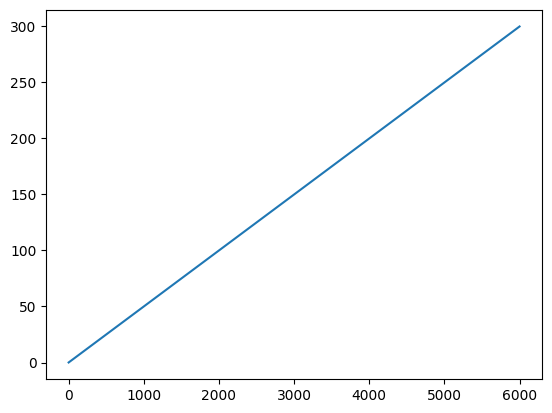

In [3]:
spikes = cinco_series[0]
plt.plot(spikes)
#plt.hist(spikes)

(224.0, 226.0)

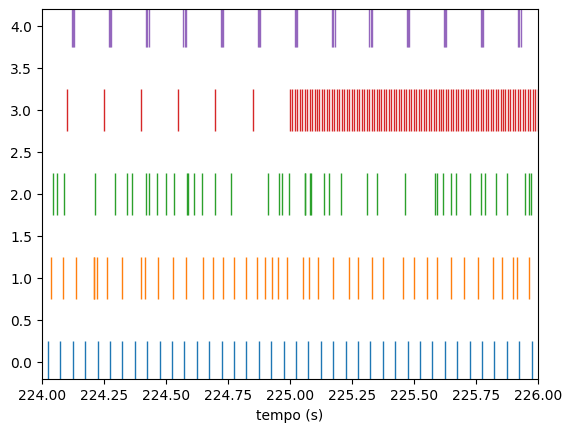

In [4]:
for i, serie in enumerate(cinco_series):
    plt.plot(serie, i * np.ones_like(serie), '|', markersize=30)
plt.xlabel('tempo (s)')
plt.xlim(224,226) # "zoom" conveniente em t
#plt.xlim(224,224.5) # "zoom" conveniente em t



# Como fazemos pra saber se uma série é regular?




(array([600., 600., 600., 600., 600., 600., 600., 600., 600., 600.]),
 array([2.50000e-02, 3.00200e+01, 6.00150e+01, 9.00100e+01, 1.20005e+02,
        1.50000e+02, 1.79995e+02, 2.09990e+02, 2.39985e+02, 2.69980e+02,
        2.99975e+02]),
 <BarContainer object of 10 artists>)

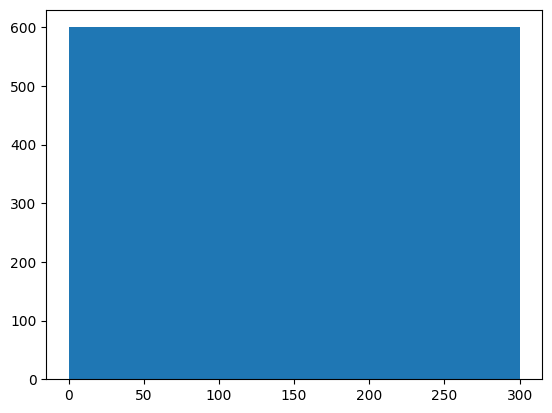

In [5]:
plt.hist(cinco_series[0])



*   Cada figura mostra o histograma dos ISIs para uma série específica de disparos, ajudando a visualizar a distribuição dos intervalos entre os disparos;
*   Os títulos das figuras informam a média dos ISIs e o coeficiente de variação, oferecendo uma visão adicional sobre a regularidade dos disparos em cada série



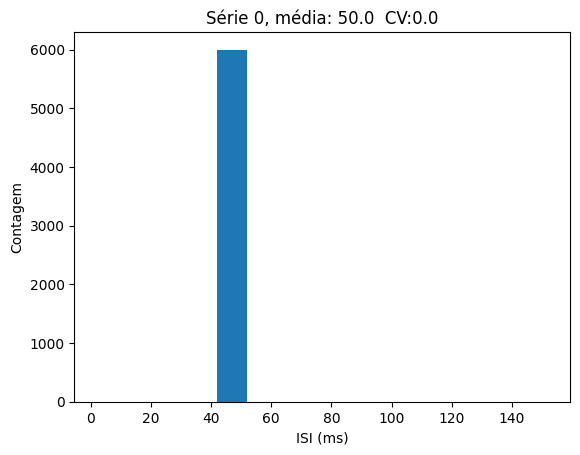

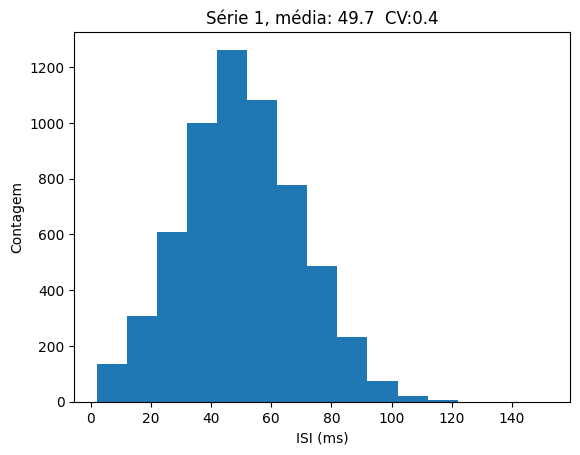

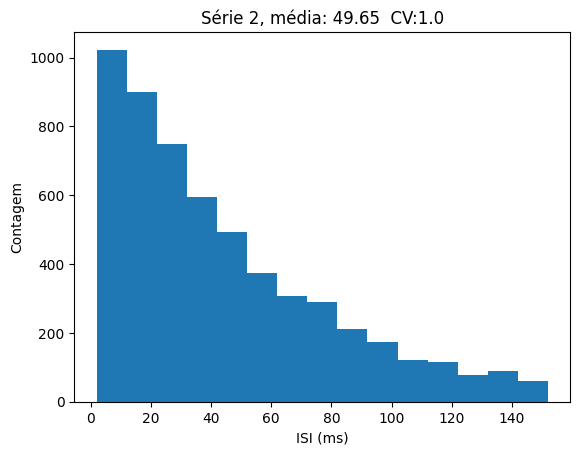

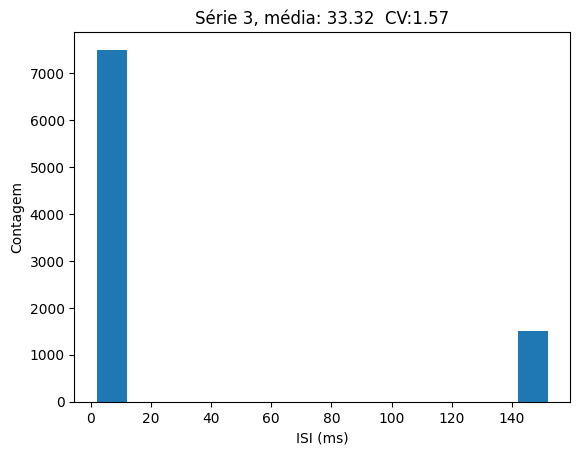

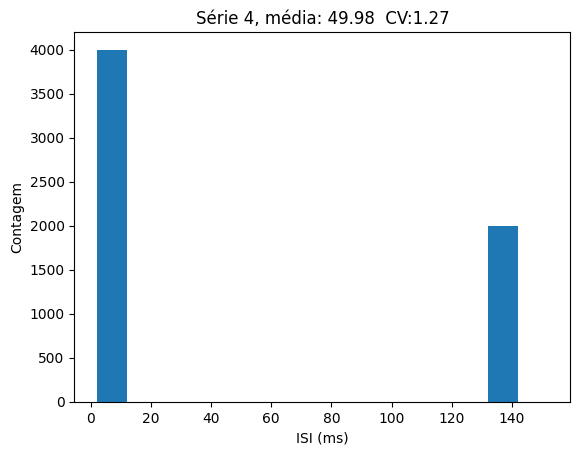

In [6]:
for i, serie in enumerate(cinco_series):
    isis = np.diff(serie) * 1000
    cv = np.std(isis)/np.mean(isis)
    plt.figure(1+i)
    plt.title(f'Série {i}, média: {round(np.mean(isis),2)}  CV:{round(cv, 2)}')
    plt.xlabel('ISI (ms)')
    plt.ylabel('Contagem')
    plt.hist(isis, np.arange(2, 156, 10))

# **Taxa de disparos dependente do tempo, PSTH**

Text(0.5, 0, 'tempo (s)')

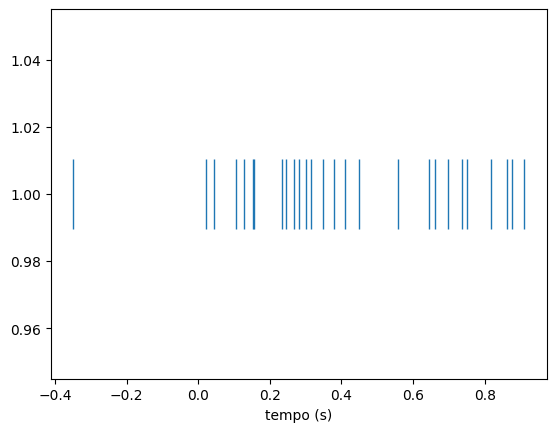

In [7]:
# O arquivo 'mil_repetidos.npy' contém séries de spikes de um mesmo neurônio,
#  para mil repetições de um experimento. Neste experimento, gravam-se os spikes
#  do neurônio por 1.5s, sendo um estímulo aplicado em t=0.5s

mil = pega_dados('mil_repetidos.npy')
n = 42 #repetição do experiemento
plt.plot(mil[n], np.ones_like(mil[n]), '|', ms=50) # disparos parecem aleatórios
plt.xlabel('tempo (s)')

CV 1.43210746176225


Text(0, 0.5, 'Contagem')

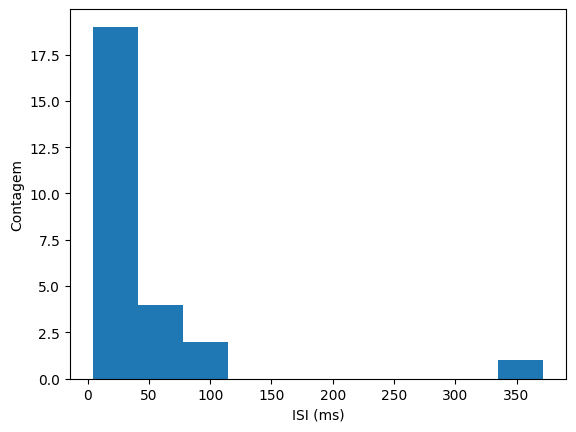

In [8]:
isi = np.diff(mil[n]) * 1000
plt.hist(isi)  # histograma dos ISI parece com qual caso acima?
print('CV', np.std(isi)/np.mean(isi))
plt.xlabel('ISI (ms)')
plt.ylabel('Contagem')

Text(0.5, 0, 'tempo em relação a início do estímulo (s)')

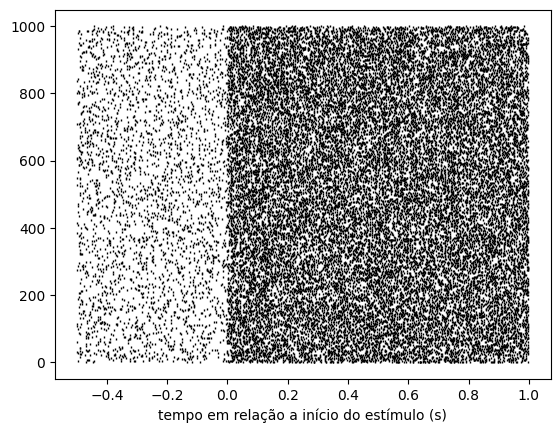

In [9]:
plt.figure(8)
for i, serie in enumerate(mil): # raster das mil repetições
    plt.plot(serie, i * np.ones_like(serie), '|k', ms=1)
plt.xlabel('tempo em relação a início do estímulo (s)')

Text(0.5, 1.0, 'PSTH mostrando mudança na taxa de disparo')

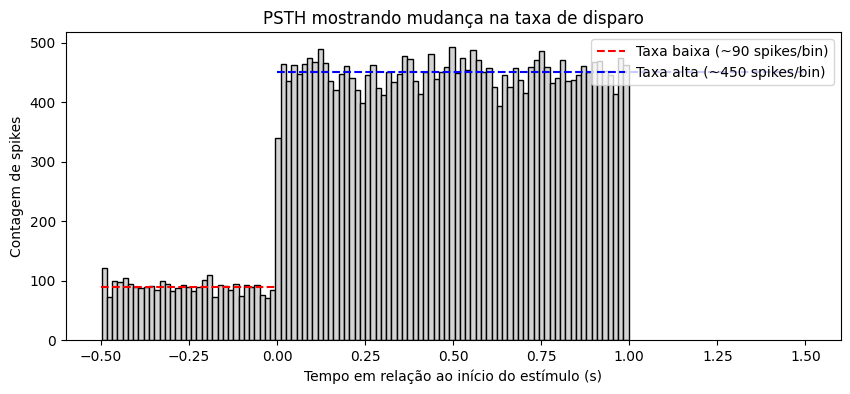

In [10]:
# Junta todos os spikes em uma única lista
todos_spikes = np.concatenate(mil)

# Cria o histograma dos tempos
plt.figure(figsize=(10,4))
contagens, bins, _ = plt.hist(
    todos_spikes,
    bins=100,
    color='lightgray',
    edgecolor='black'
)

# Linhas horizontais mostrando a média "no olho"
plt.hlines(90, -0.5, 0, colors='red', linestyles='--', label='Taxa baixa (~90 spikes/bin)')
plt.hlines(450, 0, 1.5, colors='blue', linestyles='--', label='Taxa alta (~450 spikes/bin)')

plt.xlabel('Tempo em relação ao início do estímulo (s)')
plt.ylabel('Contagem de spikes')
plt.legend()
plt.title('PSTH mostrando mudança na taxa de disparo')

